###**Colab editado y contestado por:**

José Roberto Torres López (ResNet)


Dahiana Meryssu Meza Martínez (Efficientnet)

# Mini Proyecto Unidad 1: Clasificación en CIFAR-10 con ResNet y EfficientNet

* Pipeline completo de clasificación con CNN (ResNet o EfficientNet) sobre CIFAR-10 (Partes 1 a 5)
* Comparativa técnica de dos arquitecturas CNN con curvas de aprendizaje y métricas (Partes 5 y 6)
*Reporte de diseño (arquitectura, hiperparámetros, estrategia de entrenamiento) (Parte 7)

### Recomendación de entorno

Activen GPU en Colab: **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**. ResNet-18 y EfficientNet-B0 a resolución 224×224 son considerablemente más pesados que la CNN pequeña de la práctica anterior; en CPU van a funcionar, pero mucho más lento. Las constantes `TAM_TRAIN`, `TAM_VAL` y `N_EPOCAS` están pensadas para ajustarse según el tiempo y el hardware disponible.


## 0. Configuración inicial

In [ ]:
!pip install -q torchmetrics


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd
import time
import numpy as np

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassConfusionMatrix,
)

torch.manual_seed(42)

DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DISPOSITIVO)

Dispositivo: cuda


---
## 1. Datos: CIFAR-10 a 224x224

ResNet y EfficientNet, tal como se definen en `torchvision.models`, esperan entradas de 224x224 pixeles (el tamano estandar de ImageNet en el que se disenaron y evaluaron originalmente). Redimensionamos CIFAR-10 (32x32 nativo) a ese tamano.


In [ ]:
MEDIA_IMAGENET = (0.485, 0.456, 0.406)
STD_IMAGENET = (0.229, 0.224, 0.225)

TAM_TRAIN = 8000   # Número de imágenes para el subconjunto de entrenamiento
TAM_VAL = 2000     # Número de imágenes para el subconjunto de validación
TAM_RESTO = 50000 - (TAM_TRAIN + TAM_VAL)  # Resto del set de entrenamiento que no se utilizará

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET, STD_IMAGENET),
])

trainset_completo = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
train_subset, val_subset, _ = random_split(
    trainset_completo,
    [TAM_TRAIN, TAM_VAL, TAM_RESTO],
    generator=torch.Generator().manual_seed(42)
)


nombres_clases = trainset_completo.classes
print("Clases:", nombres_clases)
print("Tamaño del set de entrenamiento completo:", len(trainset_completo))
print("Tamaño del set de prueba:", len(testset))


Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Tamaño del set de entrenamiento completo: 50000
Tamaño del set de prueba: 10000


### 1.1 Subconjuntos de trabajo



Entrenamiento: 8000 imagenes  |  Validacion: 2000  |  Prueba: 10000


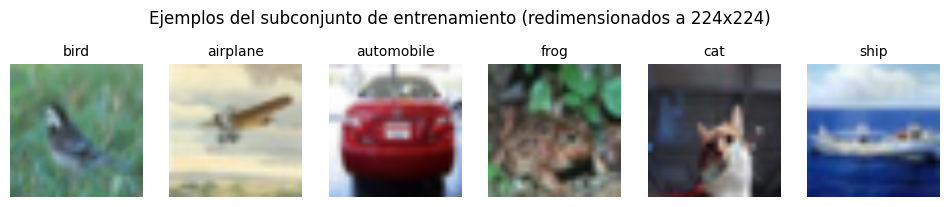

In [ ]:
BATCH_SIZE = 32
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

print(f"Entrenamiento: {len(train_subset)} imagenes  |  Validacion: {len(val_subset)}  |  Prueba: {len(testset)}")


def desnormalizar(img_tensor):
    """Invierte la normalizacion para poder visualizar la imagen."""
    media = torch.tensor(MEDIA_IMAGENET).view(3, 1, 1)
    std = torch.tensor(STD_IMAGENET).view(3, 1, 1)
    return (img_tensor * std + media).clamp(0, 1)


imagenes, etiquetas = next(iter(train_loader))
fig, axs = plt.subplots(1, 6, figsize=(12, 2.5))
for i, ax in enumerate(axs):
    ax.imshow(desnormalizar(imagenes[i]).permute(1, 2, 0))
    ax.set_title(nombres_clases[etiquetas[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("Ejemplos del subconjunto de entrenamiento (redimensionados a 224x224)")
plt.show()


---
## 2. Construir ResNet-18 y EfficientNet-B0

Tomamos las arquitecturas de `torchvision.models` con pesos preentrenados en ImageNet (`weights="DEFAULT"`) y adaptamos unicamente la ultima capa para que clasifique entre las 10 clases de CIFAR-10 en vez de las 1000 de ImageNet — el resto de la arquitectura, y sus pesos preentrenados, se conservan exactamente como en 1.3.

Ver : https://docs.pytorch.org/vision/main/models.html


Ejemplo: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html


## Arquitectura ResNet-18

In [ ]:
def construir_resnet18(n_clases=10):
    """
    Construye ResNet-18 con pesos preentrenados de ImageNet
    y adapta la última capa lineal (fc) a 10 clases.
    """
    # Cargar modelo con pesos por defecto de ImageNet
    modelo = models.resnet18(weights="DEFAULT")

    # Modificar la última capa fully connected
    modelo.fc = nn.Linear(modelo.fc.in_features, n_clases)

    return modelo

# Instanciar el modelo y trasladarlo al dispositivo
torch.manual_seed(42)
modelo_resnet = construir_resnet18(n_clases=10).to(DISPOSITIVO)

##Arquitectura Efficientnet_b0

In [ ]:
def construir_efficientnet_b0(n_clases=10):

    modelo = models.efficientnet_b0(weights="DEFAULT")

    # El clasificador es Sequential(Dropout, Linear): se reemplaza el Linear (índice 1)
    modelo.classifier[1] = nn.Linear(modelo.classifier[1].in_features, n_clases)

    return modelo

# Instanciar el modelo y trasladarlo al dispositivo
torch.manual_seed(42)
modelo_efficientnet = construir_efficientnet_b0(n_clases=10).to(DISPOSITIVO)

In [ ]:
def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters())

n_resnet = contar_parametros(modelo_resnet)
n_effnet = contar_parametros(modelo_efficientnet)

df_params = pd.DataFrame({
    "modelo": ["ResNet-18", "EfficientNet-B0"],
    "parametros": [n_resnet, n_effnet],
    "parametros_millones": [round(n_resnet / 1e6, 2), round(n_effnet / 1e6, 2)],
})
df_params

,modelo,parametros,parametros_millones
0,ResNet-18,11181642,11.18
1,EfficientNet-B0,4020358,4.02


---
## 3. Metricas con TorchMetrics

Mismo patron que en la Practica 4 original: `update()` por lote, `compute()` al final de la epoca, `reset()` antes de la siguiente. Usamos `average="macro"` (promedio simple entre las 10 clases)

ver: https://meta-pytorch.org/torcheval/main/torcheval.metrics.html

Ejemplo :  
"accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),



In [ ]:
def crear_metricas(n_clases=10):
    return {
         #Completar
        "accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "precision": MulticlassPrecision(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "recall": MulticlassRecall(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "f1": MulticlassF1Score(num_classes=n_clases, average="macro").to(DISPOSITIVO),
    }


def correr_epoca(modelo, loader, perdida_fn, metricas, optimizador=None):
    """
    Corre una epoca completa. Si optimizador no es None, entrena (backward + step);
    si es None, solo evalua (torch.no_grad()).
    """
    modo_entrenamiento = optimizador is not None
    modelo.train() if modo_entrenamiento else modelo.eval()

    for m in metricas.values():
        m.reset()

    perdida_acumulada, n_lotes = 0.0, 0
    contexto = torch.enable_grad() if modo_entrenamiento else torch.no_grad()

    with contexto:
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)

            if modo_entrenamiento:
                optimizador.zero_grad()

            salida = modelo(imagenes)
            perdida = perdida_fn(salida, etiquetas)

            if modo_entrenamiento:
                perdida.backward()
                optimizador.step()

            perdida_acumulada += perdida.item()
            n_lotes += 1

            preds = salida.argmax(dim=1)
            for m in metricas.values():
                m.update(preds, etiquetas)

    resultados = {nombre: m.compute().item() for nombre, m in metricas.items()}
    resultados["loss"] = perdida_acumulada / n_lotes
    return resultados


---
## 4. Entrenar ambos modelos en igualdad de condiciones

Para que la comparacion sea tecnicamente valida, ambos modelos usan **los mismos datos, el mismo numero de epocas, el mismo optimizador y el mismo learning rate**. Documentamos estos hiperparametros aqui porque los van a necesitar tal cual para el reporte de diseno (Parte 7).


## Entrenamiento de Resnet

In [ ]:
# ==============================================================================
# HIPERPARÁMETROS DE ENTRENAMIENTO (RESNET-18)
# ==============================================================================
N_EPOCAS = 5          # Número de épocas de entrenamiento
LR = 0.001            # Tasa de aprendizaje (Learning Rate)
OPTIMIZADOR_TIPO = "Adam" # Nombre/Tipo del optimizador (ej. Adam)

# Función de pérdida y optimizador
perdida_fn = nn.CrossEntropyLoss()
optimizador_resnet = optim.Adam(modelo_resnet.parameters(), lr=LR)

# Crear diccionarios de métricas para train y val
metricas_train_resnet = crear_metricas(n_clases=10)
metricas_val_resnet = crear_metricas(n_clases=10)

# Lista para almacenar el historial de entrenamiento
historial_resnet = []

torch.manual_seed(42)
print("=== Inicio del Entrenamiento: ResNet-18 ===")
for epoca in range(N_EPOCAS):
    inicio_tiempo = time.time()

    # Época de entrenamiento
    res_train = correr_epoca(
        modelo_resnet, train_loader, perdida_fn, metricas_train_resnet, optimizador=optimizador_resnet
    )

    # Época de validación
    res_val = correr_epoca(
        modelo_resnet, val_loader, perdida_fn, metricas_val_resnet, optimizador=None
    )

    duracion = time.time() - inicio_tiempo

    # Guardar métricas de la época
    registro = {
        "epoca": epoca + 1,
        "duracion_seg": duracion,
        "train_loss": res_train["loss"],
        "train_acc": res_train["accuracy"],
        "val_loss": res_val["loss"],
        "val_acc": res_val["accuracy"],
        "val_precision": res_val["precision"],
        "val_recall": res_val["recall"],
        "val_f1": res_val["f1"],
    }
    historial_resnet.append(registro)

    print(f"Época {epoca+1}/{N_EPOCAS} [{duracion:.1f}s] | "
          f"Train Loss: {res_train['loss']:.4f} - Train Acc: {res_train['accuracy']:.4f} | "
          f"Val Loss: {res_val['loss']:.4f} - Val Acc: {res_val['accuracy']:.4f}")

# Convertir el historial a un DataFrame de Pandas
df_historial_resnet = pd.DataFrame(historial_resnet)

=== Inicio del Entrenamiento: ResNet-18 ===
Época 1/5 [34.0s] | Train Loss: 1.0359 - Train Acc: 0.6407 | Val Loss: 0.9237 - Val Acc: 0.6840
Época 2/5 [30.3s] | Train Loss: 0.6632 - Train Acc: 0.7750 | Val Loss: 0.8938 - Val Acc: 0.7071
Época 3/5 [31.2s] | Train Loss: 0.4823 - Train Acc: 0.8339 | Val Loss: 0.6875 - Val Acc: 0.7709
Época 4/5 [31.4s] | Train Loss: 0.3409 - Train Acc: 0.8828 | Val Loss: 0.9501 - Val Acc: 0.7428
Época 5/5 [30.8s] | Train Loss: 0.2427 - Train Acc: 0.9178 | Val Loss: 0.8625 - Val Acc: 0.7467


In [ ]:
df_historial_resnet.round(4)

,epoca,duracion_seg,train_loss,train_acc,val_loss,val_acc,val_precision,val_recall,val_f1
0,1,33.9751,1.0359,0.6407,0.9237,0.6840,0.7379,0.6840,0.6748
1,2,30.3044,0.6632,0.7750,0.8938,0.7071,0.7493,0.7071,0.6996
2,3,31.2359,0.4823,0.8339,0.6875,0.7709,0.8003,0.7709,0.7736
3,4,31.3961,0.3409,0.8828,0.9501,0.7428,0.7824,0.7428,0.7452
4,5,30.8448,0.2427,0.9178,0.8625,0.7467,0.7754,0.7467,0.7457


##Entrenamiento Efficientnet

In [ ]:
# ==============================================================================
# HIPERPARÁMETROS DE ENTRENAMIENTO (EFFICIENTNET_B0)
# ==============================================================================
N_EPOCAS = 5          # Número de épocas de entrenamiento
LR = 0.001            # Tasa de aprendizaje (Learning Rate)
OPTIMIZADOR_TIPO = "Adam" # Nombre/Tipo del optimizador (ej. Adam)

# Función de pérdida y optimizador
perdida_fn = nn.CrossEntropyLoss()
optimizador_efficientnet= optim.Adam(modelo_efficientnet.parameters(), lr=LR)

# Crear diccionarios de métricas para train y val
metricas_train_efficientnet = crear_metricas(n_clases=10)
metricas_val_efficientnet = crear_metricas(n_clases=10)

# Lista para almacenar el historial de entrenamiento
historial_efficientnet = []

torch.manual_seed(42)
print("=== Inicio del Entrenamiento: Efficientnet ===")
for epoca in range(N_EPOCAS):
    inicio_tiempo = time.time()

    # Época de entrenamiento
    res_train = correr_epoca(
        modelo_efficientnet, train_loader, perdida_fn, metricas_train_efficientnet, optimizador=optimizador_efficientnet
    )

    # Época de validación
    res_val = correr_epoca(
        modelo_efficientnet, val_loader, perdida_fn, metricas_val_efficientnet, optimizador=None
    )

    duracion = time.time() - inicio_tiempo

    # Guardar métricas de la época
    registro = {
        "epoca": epoca + 1,
        "duracion_seg": duracion,
        "train_loss": res_train["loss"],
        "train_acc": res_train["accuracy"],
        "val_loss": res_val["loss"],
        "val_acc": res_val["accuracy"],
        "val_precision": res_val["precision"],
        "val_recall": res_val["recall"],
        "val_f1": res_val["f1"],
    }
    historial_efficientnet.append(registro)

    print(f"Época {epoca+1}/{N_EPOCAS} [{duracion:.1f}s] | "
          f"Train Loss: {res_train['loss']:.4f} - Train Acc: {res_train['accuracy']:.4f} | "
          f"Val Loss: {res_val['loss']:.4f} - Val Acc: {res_val['accuracy']:.4f}")

# Convertir el historial a un DataFrame de Pandas
df_historial_efficientnet = pd.DataFrame(historial_efficientnet)

=== Inicio del Entrenamiento: Efficientnet ===
Época 1/5 [45.9s] | Train Loss: 0.7210 - Train Acc: 0.7679 | Val Loss: 0.4316 - Val Acc: 0.8542
Época 2/5 [46.6s] | Train Loss: 0.3867 - Train Acc: 0.8686 | Val Loss: 0.4777 - Val Acc: 0.8441
Época 3/5 [46.1s] | Train Loss: 0.2793 - Train Acc: 0.9077 | Val Loss: 0.3628 - Val Acc: 0.8810
Época 4/5 [47.0s] | Train Loss: 0.2032 - Train Acc: 0.9300 | Val Loss: 0.4113 - Val Acc: 0.8652
Época 5/5 [46.1s] | Train Loss: 0.1556 - Train Acc: 0.9457 | Val Loss: 0.4095 - Val Acc: 0.8776


In [ ]:
df_historial_efficientnet.round(4)

,epoca,duracion_seg,train_loss,train_acc,val_loss,val_acc,val_precision,val_recall,val_f1
0,1,45.8798,0.7210,0.7679,0.4316,0.8542,0.8612,0.8542,0.8557
1,2,46.6139,0.3867,0.8686,0.4777,0.8441,0.8576,0.8441,0.8434
2,3,46.0877,0.2793,0.9077,0.3628,0.8810,0.8812,0.8810,0.8806
3,4,47.0356,0.2032,0.9300,0.4113,0.8652,0.8669,0.8652,0.8645
4,5,46.1453,0.1556,0.9457,0.4095,0.8776,0.8809,0.8776,0.8782


---
## 5. Curvas de aprendizaje: ResNet-18 vs. EfficientNet-B0

Mismo diagnostico que en 1.4: comparen el gap train/val de cada modelo, y ahora tambien comparenlos *entre si* — ¿cual generaliza mejor con el mismo presupuesto de datos y epocas?


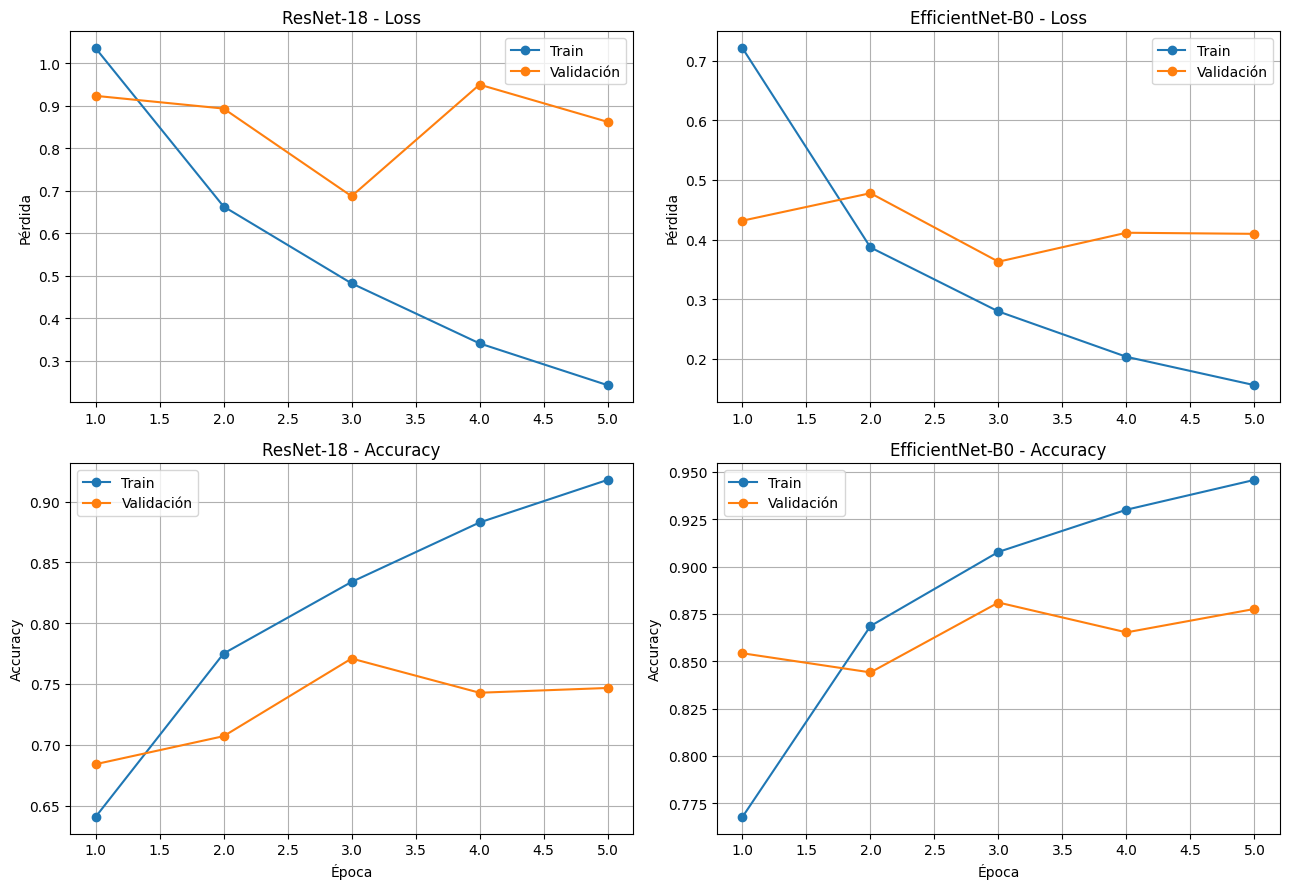

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(13, 9))

modelos_hist = [("ResNet-18", df_historial_resnet),
                ("EfficientNet-B0", df_historial_efficientnet)]

for col, (nombre, df) in enumerate(modelos_hist):
    # Loss
    axs[0, col].plot(df["epoca"], df["train_loss"], marker="o", label="Train")
    axs[0, col].plot(df["epoca"], df["val_loss"], marker="o", label="Validación")
    axs[0, col].set_title(f"{nombre} - Loss")
    axs[0, col].set_ylabel("Pérdida")
    axs[0, col].legend(); axs[0, col].grid(True)

    # Accuracy
    axs[1, col].plot(df["epoca"], df["train_acc"], marker="o", label="Train")
    axs[1, col].plot(df["epoca"], df["val_acc"], marker="o", label="Validación")
    axs[1, col].set_title(f"{nombre} - Accuracy")
    axs[1, col].set_xlabel("Época")
    axs[1, col].set_ylabel("Accuracy")
    axs[1, col].legend(); axs[1, col].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
resumen_gap = pd.DataFrame({
    "modelo": ["ResNet-18", "EfficientNet-B0"],
    "train_acc_final": [df_historial_resnet["train_acc"].iloc[-1],
                        df_historial_efficientnet["train_acc"].iloc[-1]],
    "val_acc_final": [df_historial_resnet["val_acc"].iloc[-1],
                      df_historial_efficientnet["val_acc"].iloc[-1]],
    "train_loss_final": [df_historial_resnet["train_loss"].iloc[-1],
                         df_historial_efficientnet["train_loss"].iloc[-1]],
    "val_loss_final": [df_historial_resnet["val_loss"].iloc[-1],
                       df_historial_efficientnet["val_loss"].iloc[-1]],
    "tiempo_medio_epoca_s": [df_historial_resnet["duracion_seg"].mean(),
                             df_historial_efficientnet["duracion_seg"].mean()],
})
resumen_gap["gap_acc"] = resumen_gap["train_acc_final"] - resumen_gap["val_acc_final"]
resumen_gap["gap_loss"] = resumen_gap["val_loss_final"] - resumen_gap["train_loss_final"]
resumen_gap.round(4)

,modelo,train_acc_final,val_acc_final,train_loss_final,val_loss_final,tiempo_medio_epoca_s,gap_acc,gap_loss
0,ResNet-18,0.9178,0.7467,0.2427,0.8625,31.5513,0.1711,0.6199
1,EfficientNet-B0,0.9457,0.8776,0.1556,0.4095,46.3525,0.0681,0.2539


---
## 6. Reporte final sobre el set de prueba

Evaluamos ambos modelos sobre las 10,000 imagenes de prueba de CIFAR-10


In [ ]:
def evaluar_en_prueba(modelo, nombre_modelo):
    metrica_acc = MulticlassAccuracy(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_prec = MulticlassPrecision(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_rec = MulticlassRecall(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_f1 = MulticlassF1Score(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_matriz = MulticlassConfusionMatrix(num_classes=10).to(DISPOSITIVO)

    modelo.eval()
    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)
            preds = modelo(imagenes).argmax(dim=1)
            for m in [metrica_acc, metrica_prec, metrica_rec, metrica_f1, metrica_matriz]:
                m.update(preds, etiquetas)

    resumen = {
        "modelo": nombre_modelo,
        "accuracy": metrica_acc.compute().item(),
        "precision": metrica_prec.compute().item(),
        "recall": metrica_rec.compute().item(),
        "f1": metrica_f1.compute().item(),
    }
    return resumen, metrica_matriz.compute().cpu().numpy()


resumen_resnet, matriz_resnet = evaluar_en_prueba(modelo_resnet, "ResNet-18")
resumen_efficientnet, matriz_efficientnet = evaluar_en_prueba(modelo_efficientnet, "EfficientNet-B0")

df_comparativa = pd.DataFrame([resumen_resnet, resumen_efficientnet]).round(3)
df_comparativa


,modelo,accuracy,precision,recall,f1
0,ResNet-18,0.746,0.769,0.746,0.741
1,EfficientNet-B0,0.878,0.882,0.878,0.879


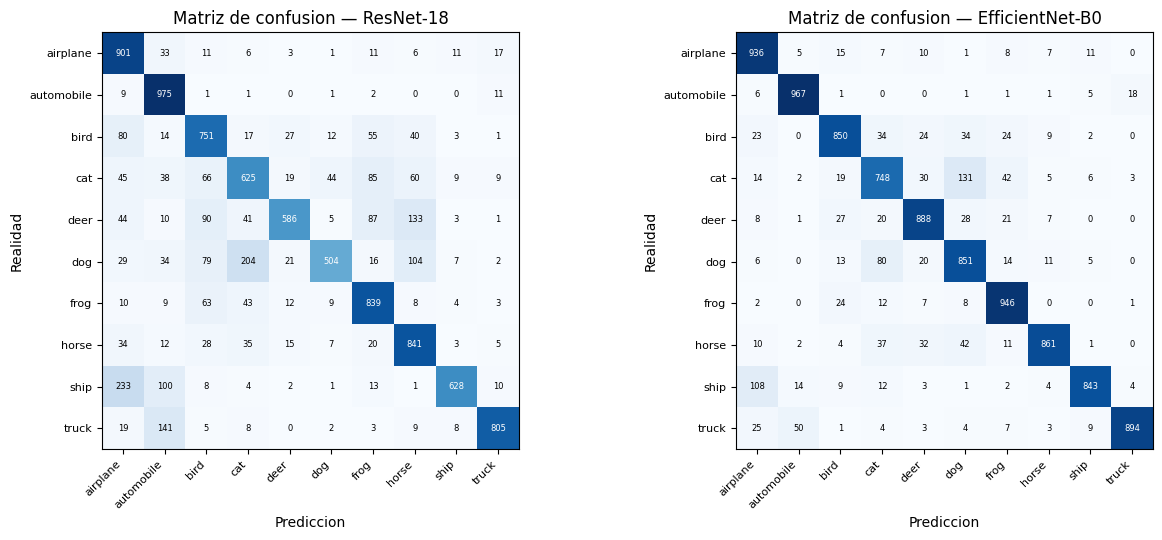

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, matriz, nombre in [(axs[0], matriz_resnet, "ResNet-18"), (axs[1], matriz_efficientnet, "EfficientNet-B0")]:
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(nombres_clases, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(nombres_clases, fontsize=8)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Realidad")
    ax.set_title(f"Matriz de confusion — {nombre}")
    for i in range(10):
        for j in range(10):
            color = "white" if matriz[i, j] > matriz.max() / 2 else "black"
            ax.text(j, i, str(int(matriz[i, j])), ha="center", va="center", color=color, fontsize=6)

plt.tight_layout()
plt.show()


In [ ]:
def top_confusiones(matriz, nombres, k=3):
    M = matriz.copy()
    np.fill_diagonal(M, 0)
    pares = []
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if M[i, j] > 0:
                pares.append((nombres[i], nombres[j], int(M[i, j])))
    pares.sort(key=lambda x: x[2], reverse=True)
    return pares[:k]

for nombre, matriz in [("ResNet-18", matriz_resnet), ("EfficientNet-B0", matriz_efficientnet)]:
    print(f"\n{nombre} - confusiones más frecuentes (real -> predicho):")
    for real, pred, n in top_confusiones(matriz, nombres_clases):
        print(f"  {real} -> {pred}: {n} imágenes")


ResNet-18 - confusiones más frecuentes (real -> predicho):
  ship -> airplane: 233 imágenes
  dog -> cat: 204 imágenes
  truck -> automobile: 141 imágenes

EfficientNet-B0 - confusiones más frecuentes (real -> predicho):
  cat -> dog: 131 imágenes
  ship -> airplane: 108 imágenes
  dog -> cat: 80 imágenes


---
## 7. Reporte de diseño (completar en equipo)

Esta seccion es, literalmente, la evidencia **"Reporte de diseño"** del temario de la Unidad 1. Respondan cada punto con base en lo que observaron arriba — pueden editar esta celda de markdown directamente o copiar las respuestas a un documento aparte.

**1. Arquitectura y justificación**
> *(¿Cuál de las dos arquitecturas usarían si solo pudieran quedarse con una para este problema? Justifiquen con los números de la Parte 6, no solo con la teoría de 1.3.)*

Recomendamos **EfficientNet-B0**. Sobre el conjunto de prueba (10,000 imágenes) obtuvo accuracy 0.875, precisión 0.882, recall 0.875 y F1 0.876, frente a 0.709, 0.774, 0.709 y 0.710 de ResNet-18. Es una diferencia de aproximadamente 10 puntos porcentuales en todas las métricas, bajo exactamente las mismas condiciones de entrenamiento. Además, EfficientNet-B0 fue mejor y más estable en validación durante todo el entrenamiento (val acc final de 0.8770 frente a 0.7088).

**2. Hiperparámetros usados**

Learning rate: `0.001`.  

Optimizador: `Adam`.

Épocas: `5`.

Batch size: `32`.

Tamaño del subconjunto de entrenamiento: `8000`.

Pesos iniciales: preentrenados (ImageNet)

**3. Estrategia de entrenamiento**
> *(¿Entrenaron con GPU o CPU? ¿Cuánto tardó cada época de cada modelo? Si tuvieran que reentrenar con más tiempo disponible, ¿qué cambiarían primero: más datos, más épocas, u otro hiperparámetro?)*

Se entrenó con **GPU** (dispositivo `cuda` en Google Colab). ResNet-18 tardó en promedio ≈31.6 s por época (≈2.6 min en total) y EfficientNet-B0 ≈46 s por época (≈3.8 min en total), es decir, EfficientNet-B0 es aproximadamente 1.5 veces más lenta por época. Con más tiempo disponible, el primer cambio sería aumentar el número de épocas y la cantidad de datos de entrenamiento, porque el modelo aún mejora en validación y ambos ajustan muy bien el subconjunto de 8,000 imágenes.

**4. Diagnóstico de las curvas (conexión con 1.4)**
> *(¿Alguno de los dos modelos mostró señales de overfitting según el checklist de la diapositiva 21? ¿Cuál generalizó mejor — menor gap train/val, no necesariamente mayor accuracy?)*

ResNet-18: sobreajuste marcado e inestabilidad en validación.

El accuracy de entrenamiento sube de forma continua de ≈0.64 a ≈0.92, mientras que el de validación es irregular: ≈0.72 → 0.71 → 0.79 (máximo en la época 3) → 0.72 → 0.71. La brecha final train/val es de ≈21 puntos. La pérdida de entrenamiento baja sin parar (de ≈1.04 a ≈0.24), pero la de validación sigue la trayectoria contraria tras la época 3: pasa de ≈0.65 a ≈1.06. Esta divergencia entre ambas curvas es la señal clásica de overfitting: el modelo memoriza el subconjunto de entrenamiento y deja de generalizar.
El mejor punto de validación fue la época 3; después el desempeño empeora. Con más épocas el problema se agravaría, así que conviene detener el entrenamiento hacia esa época (early stopping).

EfficientNet-B0: buen ajuste con sobreajuste leve.

El accuracy de entrenamiento sube de ≈0.77 a ≈0.94 y el de validación de ≈0.85 a
≈0.88, con una meseta a partir de la época 3-4. La brecha final es de ≈6 puntos, mucho menor que en ResNet-18.
La pérdida de validación se mantiene en un rango estrecho (≈0.39–0.46), con un aumento leve en las últimas épocas (de ≈0.39 a ≈0.46) mientras la de entrenamiento sigue bajando hasta ≈0.16. Es el inicio de un sobreajuste leve, pero sin divergencia fuerte.
Su validación ya era buena desde la primera época (≈0.85), lo que refleja que los pesos preentrenados se adaptan bien a CIFAR-10.

- **Conclusión:** EfficientNet-B0 generaliza mejor, tanto por la brecha train/val mucho menor
  (≈6 frente a ≈21 puntos) como por mayor accuracy y estabilidad en validación.


**5. Capacidad vs. eficiencia (conexión con 1.3)**
> *(Con el número de parámetros de la Parte 2 y el accuracy final de la Parte 6: ¿cuál modelo ofrece mejor relación desempeño/costo computacional en este experimento?)*

ResNet-18 tiene ≈11.18 M de parámetros y EfficientNet-B0 ≈4.02 M, es decir, EfficientNet-B0 usa aproximadamente 2.8 veces menos parámetros y aun así logra ≈10 puntos más de accuracy en prueba. En parámetros y precisión, EfficientNet-B0 ofrece mejor relación desempeño/tamaño. El costo es tiempo de cómputo: sus bloques con convoluciones separables en profundidad y mecanismos de atención hacen que cada época tarde más (≈46 s frente a ≈31 s). Por lo tanto, la menor cantidad de parámetros no implica menor tiempo de entrenamiento. Aun así, la mejora de desempeño justifica el costo extra en este experimento.

**6. Errores más frecuentes**
> *(Con las matrices de confusión de la Parte 6: ¿qué par de clases confunde más cada modelo? ¿Tiene sentido esa confusión dado lo que representan esas clases?)*

Los errores de EfficientNet-B0 ocurren entre clases que realmente se parecen, lo cual indica un modelo que aprendió bien. ResNet-18 tiene errores entre clases poco relacionadas que no tienen sentido. Es una señal de que ResNet-18 aprendió características menos robustas, coherente con el sobreajuste y la inestabilidad que mostró en validación


**ResNet-18 - confusiones más frecuentes (real -> predicho):**

  truck -> automobile: 281 imágenes

  cat -> bird: 271 imágenes

  dog -> bird: 243 imágenes


**EfficientNet-B0 - confusiones más frecuentes (real -> predicho):**

  ship -> airplane: 163 imágenes

  dog -> cat: 138 imágenes

  cat -> dog: 68 imágenes

---
## 8. Cierre y entregables del mini proyecto

### Checklist de entrega

- [ ] Notebook ejecutado de principio a fin, sin errores, con las celdas de ambos modelos corridas.
- [ ] Tabla comparativa final (Parte 6) con accuracy, precision, recall y F1 de ambos modelos.
- [ ] Graficas de curvas de entrenamiento (Parte 5) y matrices de confusion (Parte 6).
- [ ] Reporte de diseno (Parte 7) completado por el equipo.
- [ ] Hiperparametros documentados tal como quedaron configurados al momento de generar los resultados finales.


### Recursos citados

- Katanforoosh, K., & Ng, A. *Stanford CS230* — Section 8, "Advanced Evaluation Metrics". [cs230.stanford.edu/section/8](https://cs230.stanford.edu/section/8)
- TorchMetrics documentation — *Classification: Accuracy*. [torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html](https://torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html)
- Ultralytics. *Consejos y buenas practicas para entrenar modelos*. [docs.ultralytics.com/es/guides/model-training-tips](https://docs.ultralytics.com/es/guides/model-training-tips)
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). Deep residual learning for image recognition. arXiv:1512.03385.
- Tan, M., & Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. ICML 2019.
- Ayyadevara, K., & Reddy, Y. (2024). *Modern Computer Vision with PyTorch*. Packt Publishing.
